In [1]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# Loading the dataset
dataset = pd.read_csv("insurance_pre.csv")
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [3]:
# Categorical data - One-Hot encodinng
dataset = pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


In [4]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [5]:
# Feature selection
independent = dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
independent.head() 

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0


In [6]:
# Target or output
dependent = dataset[['charges']]
dependent.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [7]:
# Training and testing data
X_train,X_test,Y_train,Y_test = train_test_split(independent,dependent,test_size=0.3,random_state=0)

In [8]:
X_train.shape

(936, 5)

In [9]:
X_test.shape

(402, 5)

In [10]:
Y_train.shape

(936, 1)

In [11]:
Y_test.shape

(402, 1)

In [196]:
# Model training
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion='poisson',splitter='best',max_depth=6)
regressor.fit(X_train,Y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=6)

<function matplotlib.pyplot.show(close=None, block=None)>

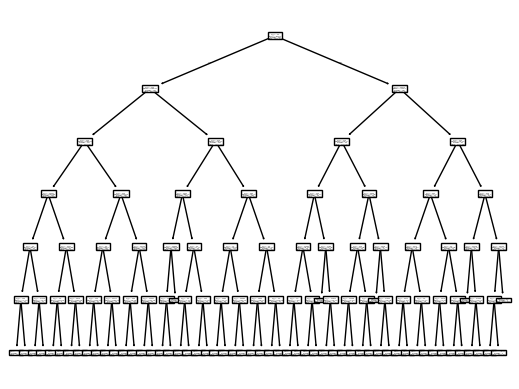

In [197]:
# Plotting the decsion tree structure
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show

In [198]:
Y_pred = regressor.predict(X_test)
Y_pred

array([11406.04206339, 11156.97502528, 46014.246084  , 13563.60712206,
        8617.60340833,  6228.27197125,  1628.24693696,  9505.86072313,
        7391.90465867,  6815.21639773,  6228.27197125, 11156.97502528,
       11156.97502528,  6228.27197125, 20591.58632286, 11156.97502528,
       14819.23989   ,  6815.21639773,  7391.90465867, 33904.1005    ,
       23926.60535938, 13727.20015393, 11406.04206339, 28742.6591    ,
        4035.31342583,  6815.21639773,  3722.96007769,  7391.90465867,
        3722.96007769, 11156.97502528,  7391.90465867, 46025.81044412,
       13563.60712206, 11406.04206339, 17358.90133611,  3722.96007769,
        8639.00828636, 43348.845735  , 40426.1088425 ,  4035.31342583,
        6228.27197125,  3722.96007769, 20591.58632286, 46025.81044412,
       36494.3823    ,  4035.31342583, 11156.97502528,  7391.90465867,
        4317.25489231, 13333.88716667,  5226.25778111,  4554.641858  ,
       28742.6591    , 50340.636555  , 11406.04206339,  3722.96007769,
      

In [199]:
# Evaluation metrics
from sklearn.metrics import r2_score
score = r2_score(Y_test,Y_pred)
score

0.8226252539898415